# Answering the Science Question
In this notebook, I am investigating the effects of seasonal monsoons on ocean stratification and circulation in the Bay of Bengal. Specifically, I will address the following science question: **How do seasonal monsoons impact ocean stratification and circulation patterns in the Bay of Bengal?**

As the Bay of Bengal experiences monsoon phases between June to September, this notebook will compare pre-monsoon and post monsoon seasons, while also taking a look at monsoon seasons.

First, import packages to re-create and visualize the model fields and define the project directory here:

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
project_dir = "F:/CS185C_DATA/model/diags"

Create the model grid

In [3]:
# define the parameters that will be used in the data file
delX = 1/12
delY = 1/14
xgOrigin = 78
ygOrigin = 0
n_rows = 360
n_cols = 260

# recreate the grids that will be used in the model
xc = np.arange(xgOrigin+delX/2, xgOrigin+n_cols*delX, delX)
yc = np.arange(ygOrigin+delY/2, ygOrigin+n_rows*delY+delY/2, delY)
XC, YC = np.meshgrid(xc, yc)

We will define January to May pre-monsoon seasons, June to September monsoon seasons, and October to December post-monsoon seasons.

To assess the impact of monsoons on ocean stratification and circulation patterns in the Bay of Bengal, we will look at May, July, and October to represent before, during, and after monsoon season. 

# Sea Surface Height
To start off, lets take a look at the difference in sea surface height between seasons.

In [4]:
grid_pre_monsoon_height = np.fromfile(os.path.join(project_dir,
                                     'EtaN_mon_mean',
                                     'EtaN_mon_mean.0000039456.data'), '>f4')
grid_pre_monsoon_height = grid_pre_monsoon_height.reshape((n_rows,n_cols))

grid_monsoon_height = np.fromfile(os.path.join(project_dir,
                                     'EtaN_mon_mean',
                                     'EtaN_mon_mean.0000057024.data'), '>f4')
grid_monsoon_height = grid_monsoon_height.reshape((n_rows,n_cols))

grid_post_monsoon_height = np.fromfile(os.path.join(project_dir,
                                     'EtaN_mon_mean',
                                     'EtaN_mon_mean.0000083520.data'), '>f4')
grid_post_monsoon_height = grid_post_monsoon_height.reshape((n_rows,n_cols))

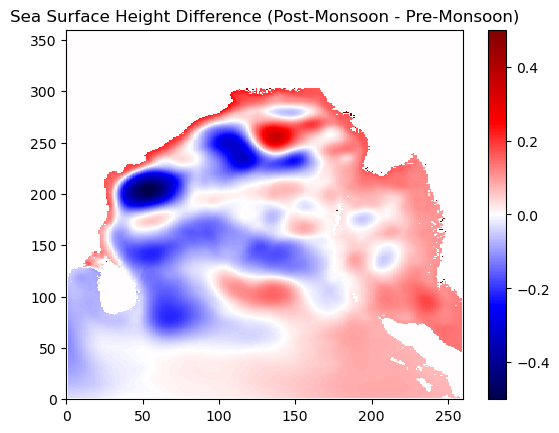

In [5]:
C = plt.pcolormesh(grid_post_monsoon_height-grid_pre_monsoon_height,
                   cmap='seismic',vmin=-0.5, vmax=0.5)
plt.colorbar(C)
plt.title('Sea Surface Height Difference (Post-Monsoon - Pre-Monsoon)')
plt.show()

From this visual, we can see that there is a general pattern of higher sea surface height along the coast in the northern and eastern parts of the Bay of Bengal during the post-monsoon period. Conversely, the southern and western parts exhibit lower sea surface height.

These trends could be attributed to the strong influx of wind and freshwater during monsoon seasons. To further explain these finding, we will look at Sea Temperature at the sea surface using the monthly results

# Sea Temperature


In [6]:
# read in the grid with the wind
grid_pre_monsoon_temp = np.fromfile(os.path.join(project_dir,
                                     'TS_3D_mon_mean',
                                     'TS_3D_mon_mean.0000039456.data'), '>f4')
grid_pre_monsoon_temp = grid_pre_monsoon_temp.reshape((2, 50,n_rows,n_cols))

grid_monsoon_temp = np.fromfile(os.path.join(project_dir,
                                     'TS_3D_mon_mean',
                                     'TS_3D_mon_mean.0000057024.data'), '>f4')
# print(grid_monsoon_temp.shape)
grid_monsoon_temp = grid_monsoon_temp.reshape((2,50, n_rows,n_cols))

grid_post_monsoon_temp = np.fromfile(os.path.join(project_dir,
                                     'TS_3D_mon_mean',
                                     'TS_3D_mon_mean.0000083520.data'), '>f4')
grid_post_monsoon_temp = grid_post_monsoon_temp.reshape((2,50,n_rows,n_cols))


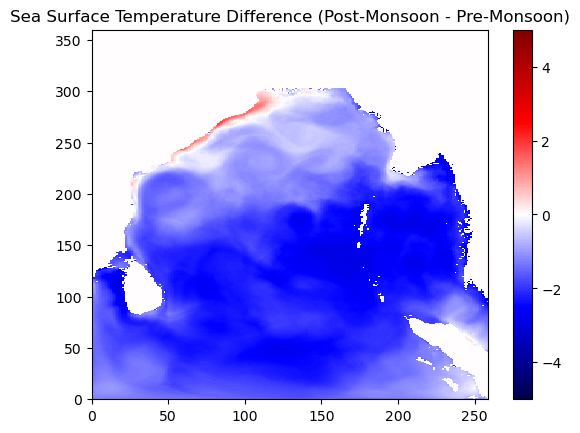

In [7]:
C = plt.pcolormesh(grid_post_monsoon_temp[0,0,:,:-1]-grid_pre_monsoon_temp[0,0,:,:-1],
                   cmap='seismic',vmin=-5, vmax=5)
plt.colorbar(C)
plt.title('Sea Surface Temperature Difference (Post-Monsoon - Pre-Monsoon)')
plt.show()

At the sea level, we can see that sea surface temperature was significantly lower during the after the monsoon season compared to pre-monsoon. This cooling could be attributed to the stronger winds during monsoon.

Next we will look at Sea Temperature at different depths.

In [8]:
#define longitude and depth
lon = np.linspace(78, 108, 260)
depth = np.linspace(0, 50, 51)

We will look at a slice near northern coast of India

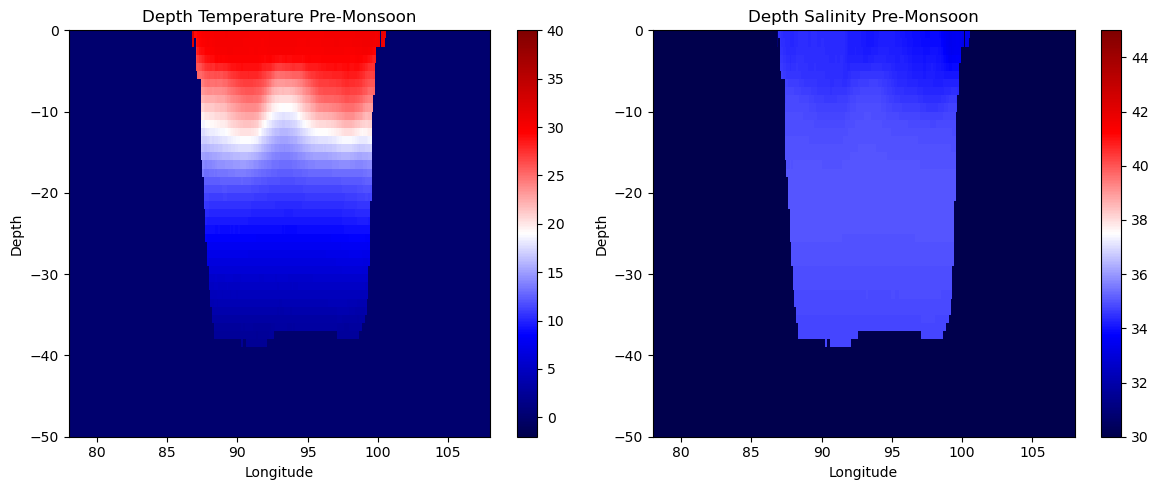

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mesh1 = axes[0].pcolormesh(lon, -depth, grid_pre_monsoon_temp[0, :, 259, :-1], vmin=-2, vmax=40, cmap='seismic')
axes[0].set_title('Depth Temperature Pre-Monsoon')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Depth')
fig.colorbar(mesh1, ax=axes[0])

mesh2 = axes[1].pcolormesh(lon, -depth, grid_pre_monsoon_temp[1, :, 259, :-1], vmin=30, vmax=45, cmap='seismic')
axes[1].set_title('Depth Salinity Pre-Monsoon')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Depth')
fig.colorbar(mesh2, ax=axes[1])

plt.tight_layout()
plt.show()


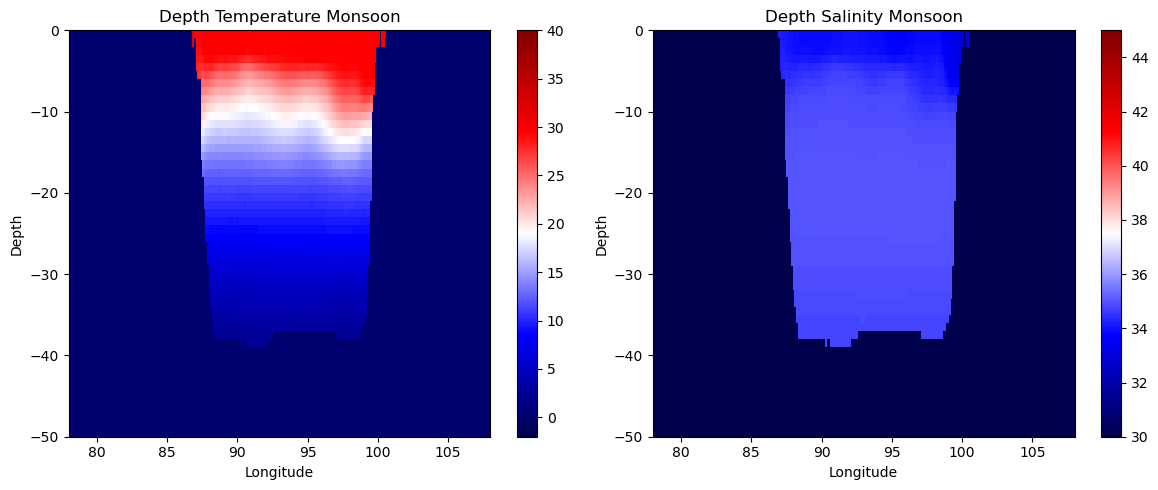

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mesh1 = axes[0].pcolormesh(lon, -depth, grid_monsoon_temp[0, :, 259, :-1], vmin=-2, vmax=40, cmap='seismic')
axes[0].set_title('Depth Temperature Monsoon')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Depth')
fig.colorbar(mesh1, ax=axes[0])

mesh2 = axes[1].pcolormesh(lon, -depth, grid_monsoon_temp[1, :, 259, :-1], vmin=30, vmax=45, cmap='seismic')
axes[1].set_title('Depth Salinity Monsoon')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Depth')
fig.colorbar(mesh2, ax=axes[1])

plt.tight_layout()
plt.show()

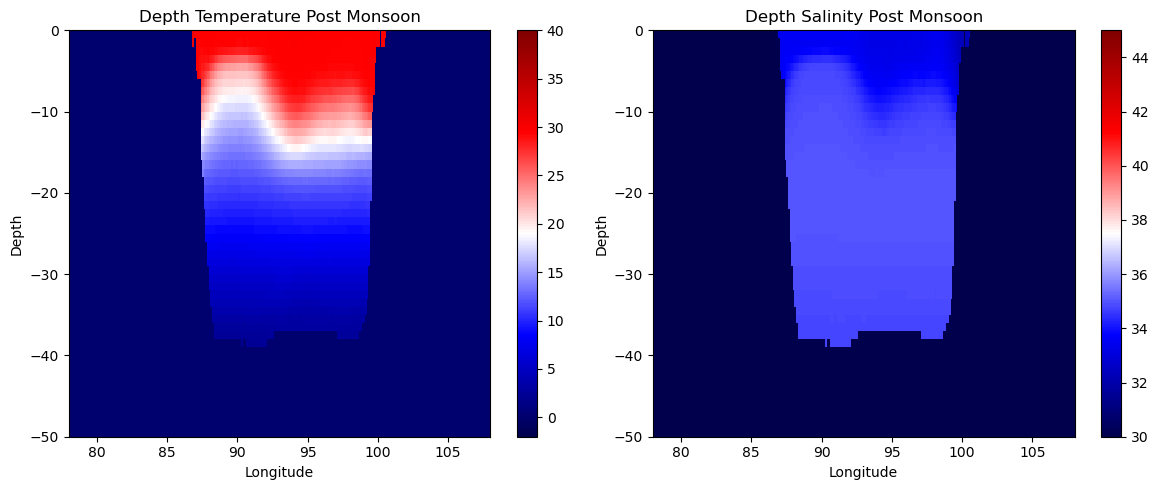

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mesh1 = axes[0].pcolormesh(lon, -depth, grid_post_monsoon_temp[0, :, 259, :-1], vmin=-2, vmax=40, cmap='seismic')
axes[0].set_title('Depth Temperature Post Monsoon')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Depth')
fig.colorbar(mesh1, ax=axes[0])

mesh2 = axes[1].pcolormesh(lon, -depth, grid_post_monsoon_temp[1, :, 259, :-1], vmin=30, vmax=45, cmap='seismic')
axes[1].set_title('Depth Salinity Post Monsoon')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Depth')
fig.colorbar(mesh2, ax=axes[1])

plt.tight_layout()
plt.show()

From this slice, we can see that monsoons significantly impact ocean stratification and circulation. The observed increase in sea surface height along the coast, as seen in the Sea Surface Height Difference visual, suggests increased freshwater input from rivers and rainfall. This reduced salinity in surface waters contributes to stronger stratification. Additionally, strong monsoon winds can induce upwelling and downwelling, bringing nutrient-rich waters to the surface and impacting the circulation patterns in the Bay of Bengal.

For further insights, lets take a look at velocity.

# Velocity

In [12]:
grid_pre_monsoon_vel = np.fromfile(os.path.join(project_dir,
                                     'vel_3D_mon_snap',
                                     'vel_3D_mon_snap.0000043776.data'), '>f4')
grid_pre_monsoon_vel = grid_pre_monsoon_vel.reshape((2,50,n_rows,n_cols))
# print(grid_pre_monsoon_vel.shape)
# print(grid_pre_monsoon_vel)

grid_monsoon_vel = np.fromfile(os.path.join(project_dir,
                                     'vel_3D_mon_snap',
                                     'vel_3D_mon_snap.0000061344.data'), '>f4')
grid_monsoon_vel = grid_monsoon_vel.reshape((2,50,n_rows,n_cols))

grid_post_monsoon_vel = np.fromfile(os.path.join(project_dir,
                                     'vel_3D_mon_snap',
                                     'vel_3D_mon_snap.0000087840.data'), '>f4')
grid_post_monsoon_vel = grid_post_monsoon_vel.reshape((2,50, n_rows,n_cols))

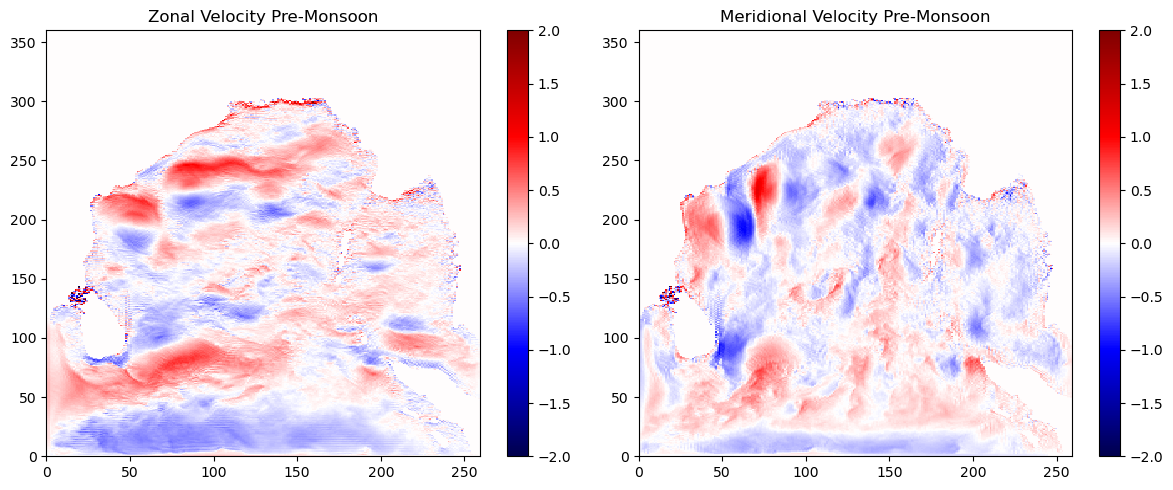

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mesh1 = axes[0].pcolormesh(grid_pre_monsoon_vel[0,0,:,:-1], vmin=-2, vmax=2, cmap='seismic')
axes[0].set_title('Zonal Velocity Pre-Monsoon')

fig.colorbar(mesh1, ax=axes[0])

mesh2 = axes[1].pcolormesh(grid_pre_monsoon_vel[1,0,:,:-1], vmin=-2, vmax=2, cmap='seismic')
axes[1].set_title('Meridional Velocity Pre-Monsoon')

fig.colorbar(mesh2, ax=axes[1])

plt.tight_layout()
plt.show()

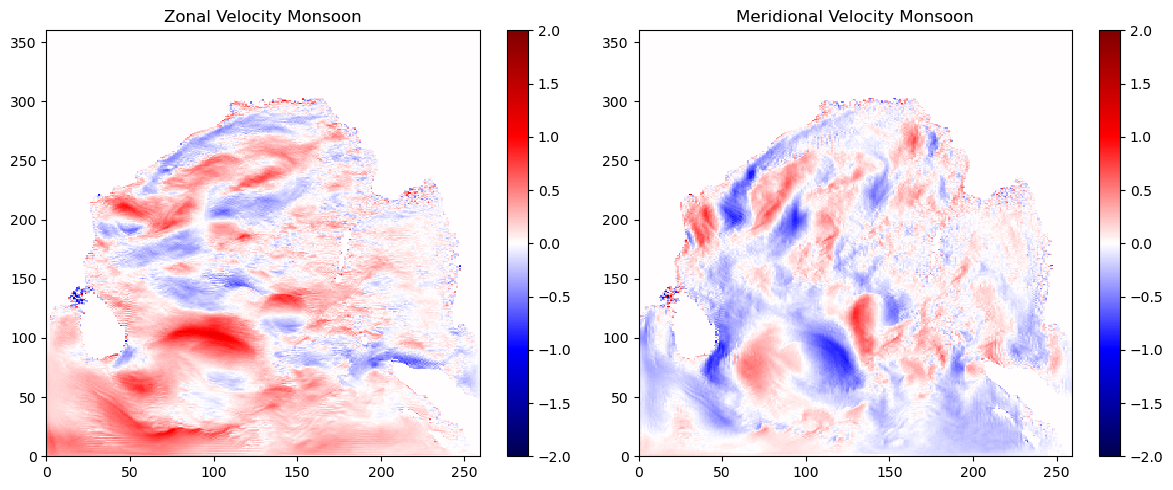

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mesh1 = axes[0].pcolormesh(grid_monsoon_vel[0,0,:,:-1], vmin=-2, vmax=2, cmap='seismic')
axes[0].set_title('Zonal Velocity Monsoon')

fig.colorbar(mesh1, ax=axes[0])

mesh2 = axes[1].pcolormesh(grid_monsoon_vel[1,0,:,:-1], vmin=-2, vmax=2, cmap='seismic')
axes[1].set_title('Meridional Velocity Monsoon')

fig.colorbar(mesh2, ax=axes[1])

plt.tight_layout()
plt.show()

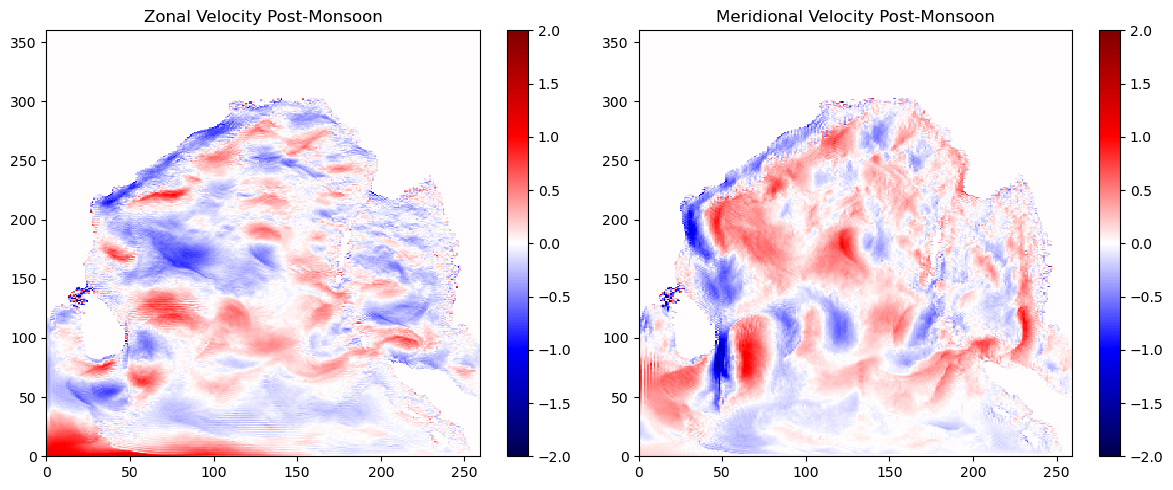

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mesh1 = axes[0].pcolormesh(grid_post_monsoon_vel[0,0,:,:-1], vmin=-2, vmax=2, cmap='seismic')
axes[0].set_title('Zonal Velocity Post-Monsoon')

fig.colorbar(mesh1, ax=axes[0])

mesh2 = axes[1].pcolormesh(grid_post_monsoon_vel[1,0,:,:-1], vmin=-2, vmax=2, cmap='seismic')
axes[1].set_title('Meridional Velocity Post-Monsoon')

fig.colorbar(mesh2, ax=axes[1])

plt.tight_layout()
plt.show()

## Pre-monsoon season
The zonal (east-west) and meridional (north-south) currents are relatively weak during the pre-monsoon season. A general eastward flow in the zonal direction and a southward flow in the meridional direction are observed within the Bay of Bengal. These velocities remain mild, which aligns with the lack of strong external forcing, such as winds or freshwater input, during this period.
## Monsoon season
During the monsoon season, a more complex and dynamic circulation pattern emerges compared to the pre-monsoon period. There is a significant increase in both eastward and southward current velocities, particularly in the zonal and meridional directions. This increase highlights the strong influence of monsoon winds in driving these currents. The enhanced wind stress and freshwater influx from rivers contribute to the disruption of stratification and the intensification of circulation across the Bay of Bengal.
## Post-monsoon season
In the post-monsoon season, the zonal velocities exhibit a notable westward flow, while the meridional velocities show a northward flow. This pattern contrasts with the strong eastward and southward currents observed during the monsoon season. The weakened influence of monsoon winds during this phase allows the ocean circulation to gradually relax, however, they still reflect the lingering influence of the monsoon winds.

# Conclusion
The seasonal monsoons exert a profound influence on the circulation patterns and stratification in the Bay of Bengal. During the monsoon season, strong winds and an increased influx of freshwater disrupt the existing stratification, leading to upwelling and downwelling. This increased circulation brings nutrient-rich waters to the surface, stimulating primary productivity. As the monsoon wanes, the system gradually returns to a more stratified state, with weaker currents.